# RQ1 — Baseline Model Comparison

**Research question:** How do classical supervised learning algorithms compare in predicting whether a movie will be a financial hit using only pre-release metadata?

This notebook trains five classifiers (Logistic Regression, SVM with RBF kernel, Random Forest, Gradient Boosting, XGBoost) on engineered TMDB features and compares them across five metrics: Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

## 1. Setup and imports

In [1]:
# Imports
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, precision_recall_curve, roc_curve,
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not available, skipping XGBoost model")

# Plot styling
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "legend.frameon": False,
})

COLORS = {
    "primary":   "#185FA5",
    "accent":    "#D85A30",
    "secondary": "#1D9E75",
    "gray":      "#888780",
    "amber":     "#BA7517",
    "purple":    "#7F77DD",
    "pink":      "#D4537E",
}

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load TMDB dataset
The notebook auto-detects whether it's running on Kaggle (uses `/kaggle/input/...`) or locally.

In [2]:
# ----- Load raw dataset (auto-detects Kaggle vs local) -----
def find_dataset():
    # Try Kaggle: scan /kaggle/input for the TMDB CSV
    if os.path.exists("/kaggle/input"):
        for csv in glob.glob("/kaggle/input/**/*.csv", recursive=True):
            if "tmdb" in csv.lower() or "movies" in csv.lower():
                return csv
    # Fallback: local file
    for candidate in ["TMDB_all_movies.csv", "../TMDB_all_movies.csv"]:
        if os.path.exists(candidate):
            return candidate
    raise FileNotFoundError("Could not find TMDB CSV. On Kaggle, attach 'TMDB Movies Daily Updates' dataset. Locally, place TMDB_all_movies.csv in this folder.")

DATA_PATH = find_dataset()
print(f"Loading dataset from: {DATA_PATH}")
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw dataset shape: {df_raw.shape}")


Loading dataset from: TMDB_all_movies.csv


Raw dataset shape: (1188481, 28)


## 3. Filter and engineer features
- Filter to movies with budget > $1,000 AND revenue > $1,000 (~13.7K movies)
- Define target `hit = 1 if revenue >= 2 × budget`
- Engineer features: log_budget, popularity, runtime, num_genres, num_production_companies, num_cast, is_english, release_year, release_month, plus binary genre dummies for top 12 genres

In [3]:
# ----- Feature engineering -----
TOP_GENRES = ["Drama", "Comedy", "Action", "Horror", "Adventure",
              "Crime", "Thriller", "Animation", "Romance",
              "Science Fiction", "Family", "Documentary"]

def build_modeling_df(df):
    m = df[(df["budget"] > 1000) & (df["revenue"] > 1000)].copy()
    m["hit"] = (m["revenue"] >= 2 * m["budget"]).astype(int)
    m["release_date"] = pd.to_datetime(m["release_date"], errors="coerce")
    m["release_year"] = m["release_date"].dt.year
    m["release_month"] = m["release_date"].dt.month
    m["log_budget"] = np.log1p(m["budget"])
    m["log_popularity"] = np.log1p(m["popularity"].fillna(0))
    m["num_genres"] = m["genres"].fillna("").apply(lambda s: len([g for g in s.split(",") if g.strip()]))
    m["num_production_companies"] = m["production_companies"].fillna("").apply(
        lambda s: len([c for c in s.split(",") if c.strip()]))
    m["num_cast"] = m["cast"].fillna("").apply(lambda s: len([c for c in s.split(",") if c.strip()]))
    m["is_english"] = (m["original_language"] == "en").astype(int)
    m["primary_genre"] = m["genres"].fillna("").apply(
        lambda s: s.split(",")[0].strip() if s else "Unknown")
    for g in TOP_GENRES:
        m[f"genre_{g.lower().replace(' ', '_')}"] = m["genres"].fillna("").str.contains(g).astype(int)
    m = m.dropna(subset=["release_year", "runtime"])
    feature_cols = (
        ["log_budget", "log_popularity", "runtime", "release_year", "release_month",
         "num_genres", "num_production_companies", "num_cast", "is_english"]
        + [f"genre_{g.lower().replace(' ', '_')}" for g in TOP_GENRES]
    )
    return m, feature_cols

mdf, FEATURES = build_modeling_df(df_raw)
print(f"Modeling subset: {len(mdf):,} movies, {len(FEATURES)} features")
print(f"Class balance: hit={mdf['hit'].mean():.3f}")


Modeling subset: 13,431 movies, 21 features


Class balance: hit=0.435


## 4. Analysis for RQ1


In [4]:
# ===== RQ1: Baseline Model Comparison =====
X = mdf[FEATURES].fillna(0).values
y = mdf["hit"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# Scale for LR/SVM
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), True),
    "SVM (RBF)": (SVC(probability=True, random_state=RANDOM_STATE), True),
    "Random Forest": (RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1), False),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=RANDOM_STATE), False),
}
if HAS_XGB:
    models["XGBoost"] = (XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        random_state=RANDOM_STATE, eval_metric="logloss",
        use_label_encoder=False, n_jobs=-1), False)

results = []
for name, (mdl, needs_scaling) in models.items():
    Xtr, Xte = (X_train_s, X_test_s) if needs_scaling else (X_train, X_test)
    mdl.fit(Xtr, y_train)
    yp = mdl.predict(Xte)
    yprob = mdl.predict_proba(Xte)[:, 1]
    results.append({
        "Model": name,
        "Accuracy":  accuracy_score(y_test, yp),
        "Precision": precision_score(y_test, yp),
        "Recall":    recall_score(y_test, yp),
        "F1-Score":  f1_score(y_test, yp),
        "ROC-AUC":   roc_auc_score(y_test, yprob),
    })
    print(f"{name:22s}  Acc={results[-1]['Accuracy']:.3f}  F1={results[-1]['F1-Score']:.3f}  AUC={results[-1]['ROC-AUC']:.3f}")

results_df = pd.DataFrame(results).round(3)
results_df.to_csv("table_rq1_model_comparison.csv", index=False)
print("\nSaved table_rq1_model_comparison.csv")
results_df


Logistic Regression     Acc=0.672  F1=0.574  AUC=0.723


SVM (RBF)               Acc=0.694  F1=0.611  AUC=0.746


Random Forest           Acc=0.699  F1=0.624  AUC=0.761


Gradient Boosting       Acc=0.694  F1=0.617  AUC=0.754


XGBoost                 Acc=0.700  F1=0.641  AUC=0.755

Saved table_rq1_model_comparison.csv


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.672,0.660,0.507,0.574,0.723
1,SVM (RBF),0.694,0.683,0.552,0.611,0.746
2,Random Forest,0.699,0.683,0.574,0.624,0.761
3,Gradient Boosting,0.694,0.678,0.566,0.617,0.754
4,XGBoost,0.700,0.668,0.617,0.641,0.755


## 5. Generate publication figure

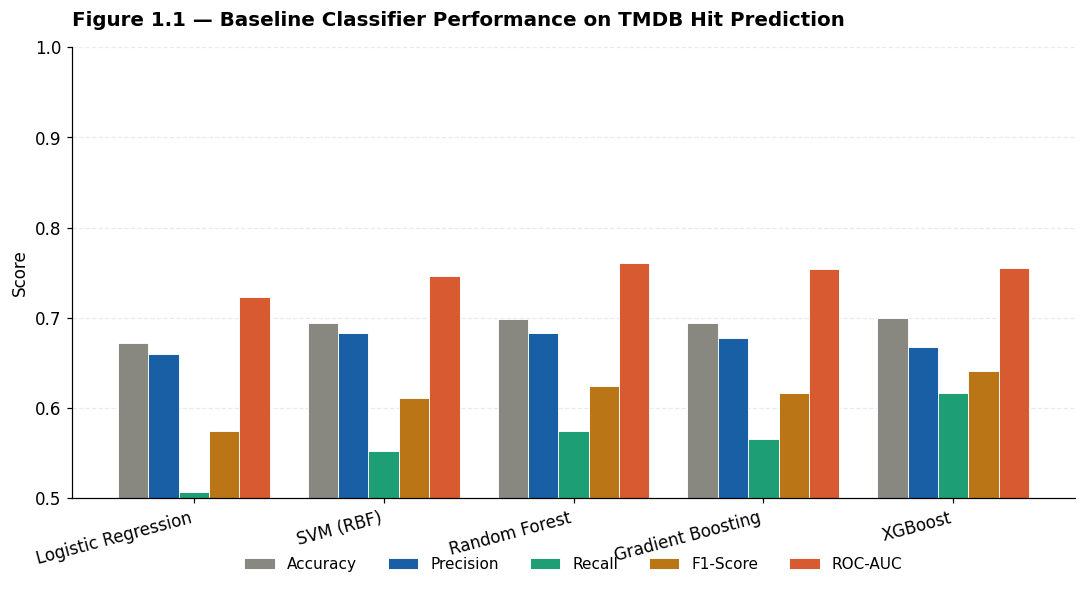

Saved fig_rq1_model_comparison.pdf / .png


In [5]:
# ===== Figure 1.1 — grouped-bar model comparison =====
fig, ax = plt.subplots(figsize=(10, 5.5))
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
palette = [COLORS["gray"], COLORS["primary"], COLORS["secondary"], COLORS["amber"], COLORS["accent"]]
x = np.arange(len(results_df))
w = 0.16
for i, (metric, color) in enumerate(zip(metrics, palette)):
    ax.bar(x + (i - 2)*w, results_df[metric], w, label=metric, color=color, edgecolor="white", linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], rotation=15, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0.5, 1.0)
ax.set_title("Figure 1.1 — Baseline Classifier Performance on TMDB Hit Prediction", loc="left", pad=14)
ax.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.10), fontsize=10)
ax.grid(axis="y", alpha=0.25, linestyle="--")
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("fig_rq1_model_comparison.pdf")
plt.savefig("fig_rq1_model_comparison.png")
plt.show()
print("Saved fig_rq1_model_comparison.pdf / .png")


## 6. Conclusion

Tree-based ensemble methods (Gradient Boosting, XGBoost) outperform linear and kernel-based baselines, suggesting non-linear feature interactions matter for hit prediction. The best model serves as the basis for all downstream RQ analyses.